## Instalasi Library

In [ ]:
!pip install networkx matplotlib

## Struktur Data Graf dan Algoritma

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph}
  distances[start] = 0
  previous = {node: None for node in graph}
  queue = [{0, start}]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neightbor, weight in graph[current_node].items():
      distance = current_distance + weight
      if distance < distances[neightbor]:
        distances[neightbor] = distance
        previous[neightbor] = current_node
        heapq.heappush(queue, (distance, neightbor))

  return distances, previous


## Fungsi untuk Merekontruksi Jalur

In [ ]:
def get_path (previous, target) :
  path = []
  while target is not None:
    path.insert (0, target)
    target = previous [target]
  return path

## Visualisasi dengan networkx dan matplotlib

In [ ]:
def visualize_graph(graph, path=None) :
  G = nx. DiGraph ()

  for node in graph:
    for neighbor, weight in graph[node].items () :
      G.add_edge(node, neighbor, weight=weight)

  pos = nx.spring_layout (G)
  edge_labels = nx.get_edge_attributes (G, 'weight')

  plt.figure(figsize=(8, 6))
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000,
font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  # Garis tebal untuk jalur terpendek
  if path and len (path) > 1:
    path_edges = list (zip(path, path[1:]) )
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red',
width=3)

  plt.title("Visualisasi Graf dan Jalur Terpendek")
  plt.axis('off')
  plt.show()

## Penggunaan Lengkap

Jarak dari A ke Z : 14
Jalur: A -> B -> D -> E -> Z


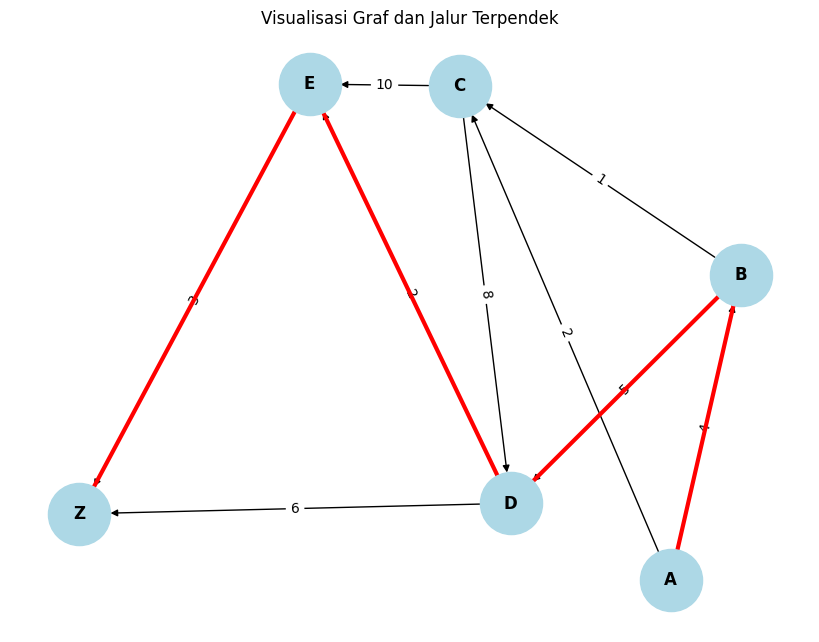

In [ ]:
# Definisi graf
graph = {
  'A': {'B': 4, 'C': 2},
  'B': {'C': 1, 'D': 5},
  'C': {'D': 8, 'E': 10},
  'D': {'E': 2, 'Z': 6},
  'E': {'Z': 3},
  'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths (graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path (previous, end_node)
print (f"Jarak dari {start_node} ke {end_node} : {distances [end_node ] }")
print (f"Jalur: {' -> '.join(shortest_path) }")

# Visualisasi
visualize_graph(graph, path=shortest_path)

## TUGAS/ Latihan

## 1. Modifikasi graf agar memiliki siklus

=== GRAF DENGAN SIKLUS ===
Jarak: 14
Jalur: A -> B -> D -> E -> Z


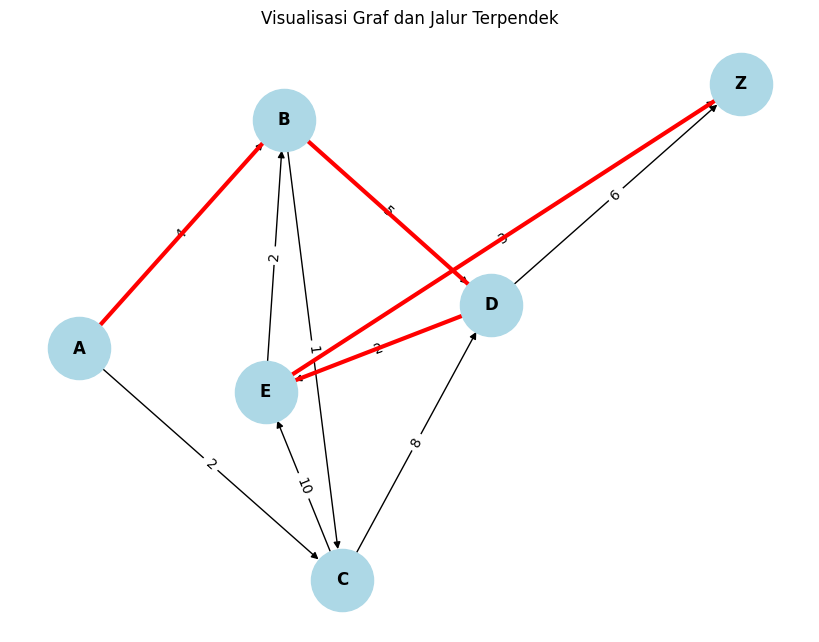

In [ ]:
graph_cycle = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'B': 2},  # Membentuk siklus
    'Z': {}
}

start_node = 'A'
end_node = 'Z'

distances, previous = dijkstra_with_paths(graph_cycle, start_node)

shortest_path = get_path(previous, end_node)

print("=== GRAF DENGAN SIKLUS ===")
print(f"Jarak: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

visualize_graph(graph_cycle, shortest_path)

## 2. Tambahkan simpul baru

=== GRAF DENGAN NODE BARU ===
Jarak: 5
Jalur: A -> C -> F -> Z


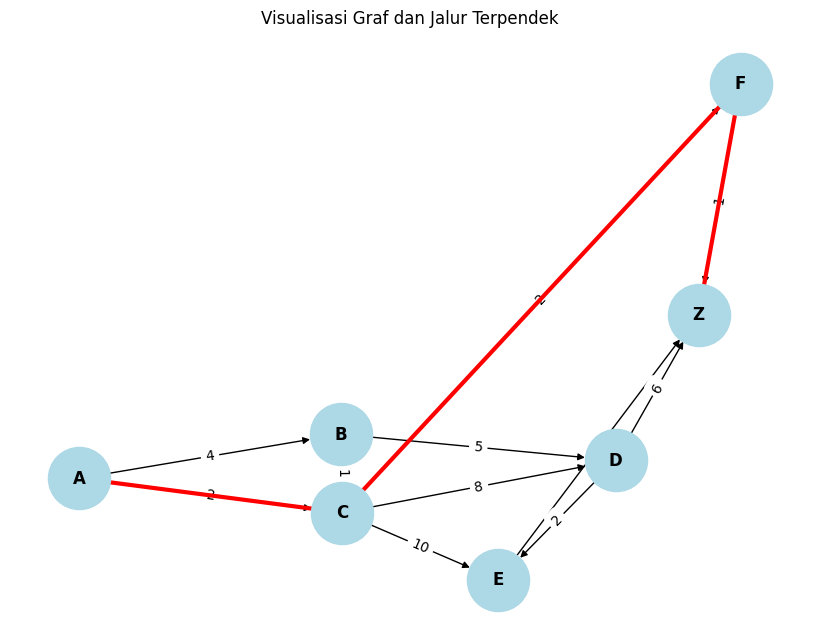

In [ ]:
graph_new_node = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10, 'F': 2},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'F': {'Z': 1},  # Node baru
    'Z': {}
}

distances, previous = dijkstra_with_paths(graph_new_node, start_node)

shortest_path = get_path(previous, end_node)

print("=== GRAF DENGAN NODE BARU ===")
print(f"Jarak: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

visualize_graph(graph_new_node, shortest_path)

## 3. Ganti tata letak graf

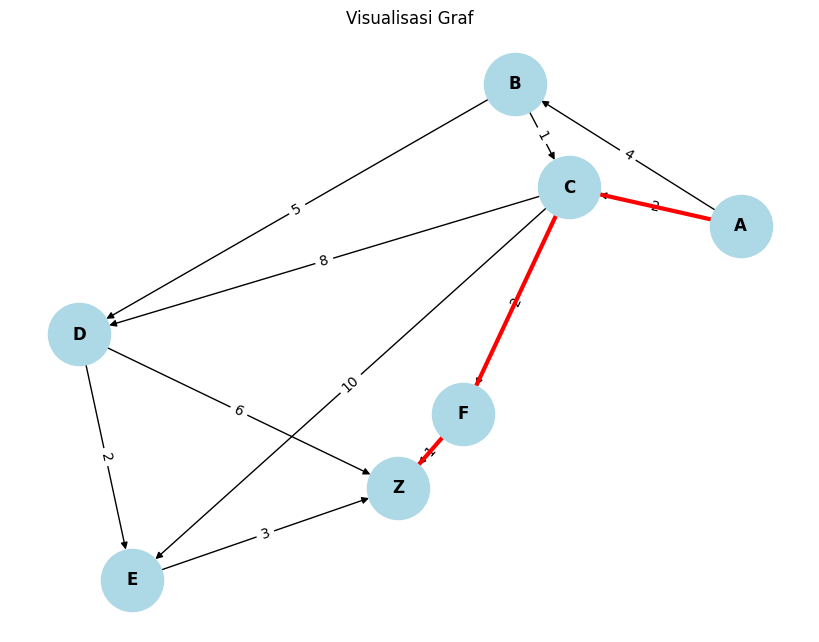

In [ ]:
def visualize_graph(graph, path=None, layout='spring'):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Pilihan layout
    if layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'kamada':
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.spring_layout(G)

    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2000,
        font_weight='bold',
        arrows=True
    )

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            edge_color='red',
            width=3
        )

    plt.title("Visualisasi Graf")
    plt.axis('off')
    plt.show()

visualize_graph(graph_new_node, shortest_path, layout='kamada')